<a href="https://colab.research.google.com/github/chantellgebauer/AnalisisNotas/blob/main/Predicci%C3%B3nSalarial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresión Lineal, que predice y marca una linea recta en los datos que se calculan a 15 años de salario.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#Asegurarnos de haber subido el archivo
df = pd.read_csv("Salary.csv")
#Verificamos que ha cargado bien.
print(df.head())


   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


Coheficiente de determinación(R^2): 0.9708
Error cuadrático Medio(MSE): 16561691.22


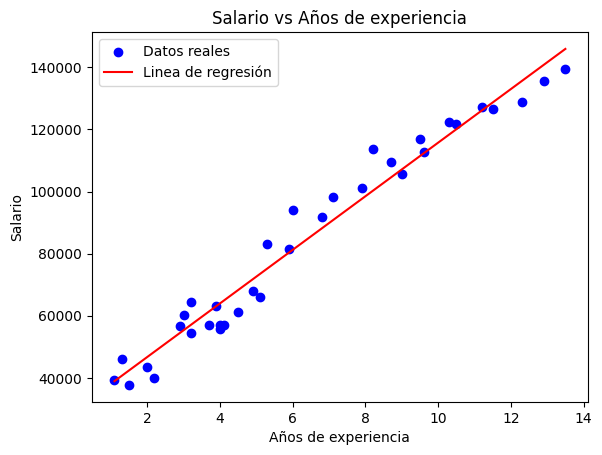

In [8]:
#Paso1: La preparación de los datos
#Convertimos las columnas a valores numéricos(arrays en numpy) para scikit-learn.
# X debe ser una matriz bidimensional(n_muestras, n_características)
X = df[["YearsExperience"]].values.reshape(-1,1)
# y es el vectir objetivo (nuestro salario), una matriz unidimensional
y = df["Salary"].values


#Paso 2: División de los datos(train/test)
#importamos la funcion para separar los datos
from sklearn.model_selection import train_test_split
#Dividimos 80% para entrenar el modelo y 20% para probar su precisión
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Paso #3 Entrenamiento del modelo
#Creamos la instancia del modelo de regresión lineal
model = LinearRegression()
#Entrenamos el modelo: Aquí es donde la IA aprende
#la relación lineal entre X e y
model.fit(X_train, y_train)

#Paso 4 : Predicción y evaluación
#Hacemos predicciones usando los datos de prueba (que el modelo nunca vio)
y_pred =model.predict(X_test)

#importamos metricas de evaluación
from sklearn.metrics import r2_score, mean_squared_error

#Calculamos R^2: indica que tan bien se ajusta el modelo a los datos(1.0 es perfecto)
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print(f"Coheficiente de determinación(R^2): {r2:.4f}")
print(f"Error cuadrático Medio(MSE): {mse:.2f}")

#Paso 5 Visualización
#Pintamos los datos reales.
plt.scatter(X, y, color ='blue', label='Datos reales')
#pintamos la linea roja que es lo que el modelo ha aprendido
plt.plot(X, model.predict(X), color='red', label='Linea de regresión')
plt.title('Salario vs Años de experiencia')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.legend()
plt.show()